## Regress out taks effect in risk task time series for GM analysis

to investigate where the special anchoring of the average (and also for some individuals) risk-task gradient comes from, regress out task effects --> does it look more like the standard resting state gradient then?

* all in surface space: `nilearn.glm.first_level.run_glm` (`nilearn.glm.first_level.FirstLevelModel` only works with niimg like objects, so )
    * design matrix: 
    * estimation: `noise_model ='ols'` crucial! (something with autocorrelation)
* just created DM and add it to `confounds` of `clean_ts = signal.clean(timeseries.T, confounds=fmriprep_confounds).T` in `cleanTS()` of the gradient fitting procedure
    * took normal event files and substracted 0.8/0.6 (stim1/stim2) at the onset for the piechart presentation
    * added this now to gradients.utils as `get_events_confounds` and the option to automatically employ it in `cleanTS()`

### look at results !

In [236]:
import nilearn 
import os.path as op
from nilearn import image
import os
import numpy as np
import pandas as pd

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'


In [2]:
import json
with open(op.join(bids_folder, 'sub-01', 'ses-1','func', 'sub-01_ses-1_task-risk_run-1_bold.json'), # 'derivatives/fmriprep' , 
    "rt",
) as fp:
    task_info = json.load(fp)
TR = task_info["RepetitionTime"]
Nslices = len(task_info['SliceTiming']) # = 39
refSlice = 20 #Nslices / 2

In [165]:
from stress_risk.utils import Subject
from nilearn import surface

sub=1
subject = f'{sub:02d}'
ses = 1
session = ses
derivatives = op.join(bids_folder, 'derivatives')
base_dir = 'glm_nilearn.residuals'
base_dir = op.join(derivatives, base_dir, f'sub-{subject}', f'ses-{session}', 'func')
os.makedirs(base_dir, exist_ok=True)

sub = Subject(sub, bids_folder=bids_folder)

ims = sub.get_preprocessed_bold_surf(session=ses, space='fsaverage5', hemis=['L'])
data = [surface.load_surf_data(im) for im in ims]



file exists:True


In [8]:
value=False
onsets = sub.get_fmri_events(session=session, runs = range(1, 7), value=value)
tr = 2.3 # repetition Time
n = 135  # number of slices
frametimes = np.linspace(tr/2., (n - .5)*tr, n)
onsets['onset'] = ((onsets['onset']+tr/2.) // 2.3) * 2.3
onsets.drop(columns=['n2', 'trial_nr'], inplace=True)
onsets.head()

,onset,trial_type,duration
run,,,
1,13.8,trial_001_n1,0.6
1,34.5,n2_7,0.6
1,50.6,n2_7,0.6
1,64.4,n2_28,0.6
1,75.9,n2_10,0.6


In [6]:
# code from fit_glm.py (denoise for encoding!)
from nilearn.glm.first_level import make_first_level_design_matrix
runs = range(1, 7)
dm = [make_first_level_design_matrix(frametimes, onsets.loc[run], hrf_model='fir', oversampling=100.,
                                         drift_order=1,
                                         drift_model=None).drop('constant', axis=1) for run in runs]

dm = pd.concat(dm, keys=range(1, 7), names=['run']).fillna(0)
dm.columns = [c.replace('_delay_0', '') for c in dm.columns]
dm /= dm.max()
#print(dm)
dm[dm < 1.0] = 0.0
print(dm.shape)

from nilearn.plotting import plot_design_matrix
plot_design_matrix(dm)

# --> wrong format


(810, 142)


## new event files including prob (as piechart presentation)

In [11]:

sub='01'
df = pd.read_csv(op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-1_events_allEvents.tsv'.format(sub=sub, ses=ses)), sep='\t')
df.head()

,trial_nr,onset,trial_type,prob1,prob2,n1,n2,n,prob,choice
0,0,2.301951,stim1 prob,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,12.461733,stim1 prob,0.55,1.0,13.0,10.0,NaN,0.55,NaN
2,1,13.262186,stim1 dots,0.55,1.0,13.0,10.0,13.0,NaN,NaN
3,1,18.867192,stim2 prob,0.55,1.0,13.0,10.0,NaN,1.00,NaN
4,1,19.467741,stim2 dots,0.55,1.0,13.0,10.0,10.0,NaN,NaN


In [15]:
behavior = []
for run in range(1, 7):
    df = pd.read_csv(op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-1_events_allEvents.tsv'.format(sub=sub, ses=ses)), sep='\t')
    behavior.append(df)
behavior = pd.concat(behavior, keys=runs, names=['run'])
behavior = behavior.reset_index().set_index(['run', 'trial_type'])
behavior.head()


level_1  trial_nr      onset  prob1  prob2    n1    n2     n  \
run trial_type                                                                 
1   stim1 prob        0         0   2.301951    NaN    NaN   NaN   NaN   NaN   
    stim1 prob        1         1  12.461733   0.55    1.0  13.0  10.0   NaN   
    stim1 dots        2         1  13.262186   0.55    1.0  13.0  10.0  13.0   
    stim2 prob        3         1  18.867192   0.55    1.0  13.0  10.0   NaN   
    stim2 dots        4         1  19.467741   0.55    1.0  13.0  10.0  10.0   

                prob  choice  
run trial_type                
1   stim1 prob   NaN     NaN  
    stim1 prob  0.55     NaN  
    stim1 dots   NaN     NaN  
    stim2 prob  1.00     NaN  
    stim2 dots   NaN     NaN

In [73]:
stimulus1 = behavior.xs('stim1 prob', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n1']]
stimulus1['duration'] = 0.6 + 0.8
stimulus1['stim_order'] = int(1)

stimulus1_int = stimulus1.copy()
stimulus1_int['trial_type'] = 'stimulus1_int'
stimulus1_int['modulation'] = 1
stimulus1_mod= stimulus1.copy()
stimulus1_mod['trial_type'] = 'stimulus1_mod'
stimulus1_mod['modulation'] = stimulus1['n1']

choices = behavior.xs('choice', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]

stimulus2 = behavior.xs('stim2 prob', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]
stimulus2['duration'] = choices['onset'] - stimulus2['onset'] # 0.6 + 0.6 ## looked at the data, is is different for stim 1 and 2... ?!!
stimulus2['stim_order'] = int(2)

stimulus2_int = stimulus2.copy()
stimulus2_int['trial_type'] = 'stimulus2_int'
stimulus2_int['modulation'] = 1
stimulus2_mod= stimulus2.copy()
stimulus2_mod['trial_type'] = 'stimulus2_mod'
stimulus2_mod['modulation'] = stimulus2['n2']

events = pd.concat((stimulus1_int,stimulus1_mod, stimulus2_int, stimulus2_mod)).set_index(['trial_nr','stim_order'],append=True).sort_index()
events = events[~ events.index.get_level_values('trial_nr').isin([0])] # drop trial 0
events

onset     trial_type    n1  duration  \
run trial_nr stim_order                                              
1   1        1            12.461733  stimulus1_int  13.0  1.400000   
             1            12.461733  stimulus1_mod  13.0  1.400000   
             2            18.867192  stimulus2_int   NaN  1.077523   
             2            18.867192  stimulus2_mod   NaN  1.077523   
    2        1            25.123011  stimulus1_int   8.0  1.400000   
...                             ...            ...   ...       ...   
6   19       2           285.063624  stimulus2_mod   NaN  1.305927   
    20       1           291.820657  stimulus1_int   7.0  1.400000   
             1           291.820657  stimulus1_mod   7.0  1.400000   
             2           299.210019  stimulus2_int   NaN  1.272849   
             2           299.210019  stimulus2_mod   NaN  1.272849   

                         modulation    n2  
run trial_nr stim_order                    
1   1        1                  1.0   NaN  
             1                 13.0   NaN  
             2                  1.0  10.0  
             2                 10.0  10.0  
    2        1                  1.0   NaN  
...                             ...   ...  
6   19       2                 16.0  16.0  
    20       1                  1.0   NaN  
             1                  7.0   NaN  
             2                  1.0  11.0  
             2                 11.0  11.0  

[480 rows x 6 columns]

In [79]:
tr = 2.3 # repetition Time
n = 135  # number of slices
frametimes = np.linspace(tr/2., (n - .5)*tr, n)

onsets = events[['onset', 'duration', 'trial_type', 'modulation']] # #events.drop(columns=['n2', 'trial_nr', ], inplace=True)
onsets['onset'] = ((onsets['onset']+tr/2.) // 2.3) * 2.3
onsets.head()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_6821/680883242.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  onsets['onset'] = ((onsets['onset']+tr/2.) // 2.3) * 2.3


onset  duration     trial_type  modulation
run trial_nr stim_order                                            
1   1        1            11.5  1.400000  stimulus1_int         1.0
             1            11.5  1.400000  stimulus1_mod        13.0
             2            18.4  1.077523  stimulus2_int         1.0
             2            18.4  1.077523  stimulus2_mod        10.0
    2        1            25.3  1.400000  stimulus1_int         1.0

In [149]:
run = 2

A 'modulation' column was found in the given events data and is used.
(135, 12)


<AxesSubplot:label='conditions', ylabel='scan number'>

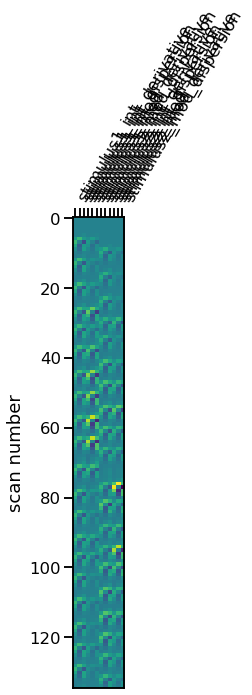

In [150]:
from nilearn.glm.first_level import make_first_level_design_matrix
dm = make_first_level_design_matrix(frametimes, onsets.loc[run], 
                                     hrf_model='spm + derivative + dispersion', 
                                     oversampling=100.,drift_order=1, 
                                     drift_model=None).drop('constant', axis=1) 

# add_regs: array of shape(n_frames, n_add_reg)/ DataFrame

dm.columns = [c.replace('_delay_0', '') for c in dm.columns]
dm /= dm.max()
print(dm.shape)

from nilearn.plotting import plot_design_matrix
plot_design_matrix(dm)


### run 1st level estimation

In [151]:
data[run-1].shape

(10242, 135)

In [152]:
ims = sub.get_preprocessed_bold_surf(session=ses, space='fsaverage5', hemis=['L'])
data = [surface.load_surf_data(im) for im in ims]

#data = np.concatenate(data, axis=1)
print(['data:', data[run-1].shape])
print(['DM:', dm.shape])


file exists:True
['data:', (10242, 135)]
['DM:', (135, 12)]


In [156]:
from nilearn.glm.first_level import run_glm
# data - Y: array of shape (n_time_points, n_voxels)
# design matrix - X: array of shape (n_time_points, n_regressors)

labels, results = run_glm(data[run-1].T, dm.values, noise_model='ols')
print(len(results.keys()) )
keys = list(results.keys())


1


In [160]:
np.shape(results[0.0].residuals)

(135, 10242)

10242


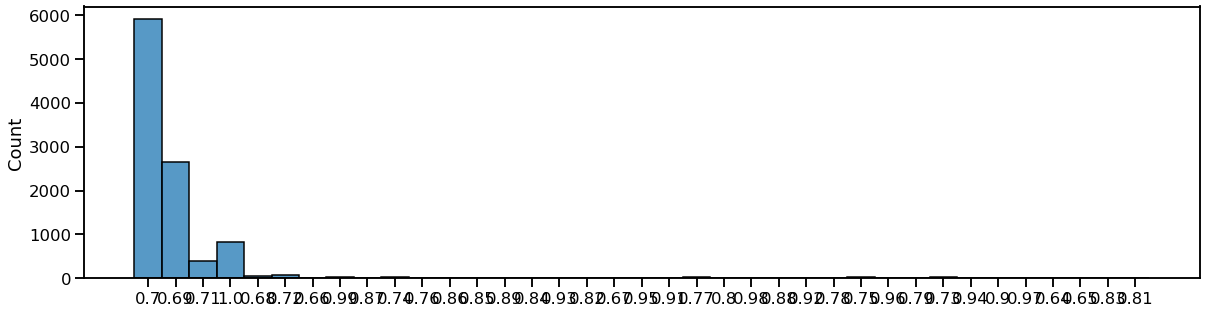

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('talk')
fig, ax = plt.subplots(figsize=(20,5))
print(len(labels))
sns.histplot(labels, bins=1000, ax=ax)
plt.show()


In [145]:
# labels: array (n_voxels,); A map of values on voxels used to identify the corresponding model.
# results: dict; keys - label values, len()=141= #regressors - 1 
# len(results['key1']'= n_voxels = 10242 : values are RegressionResults instances corresponding to the voxels.\
print(results[keys[0]].__dir__()[:15])
results
print(len(results[keys[0]].residuals)) # N_timepoints
#results[keys[0]].Tcontrast

['theta', 'Y', 'model', 'cov', 'dispersion', 'nuisance', 'df_total', 'df_model', 'df_residuals', 'whitened_Y', 'whitened_residuals', 'whitened_design', 'predicted', 'residuals', 'resid']
135


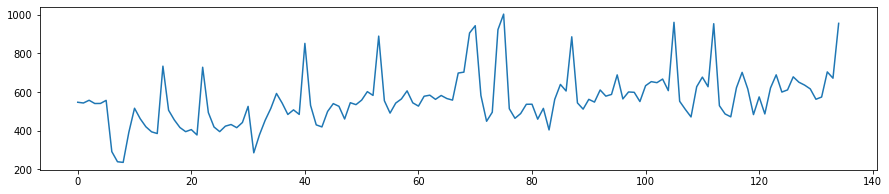

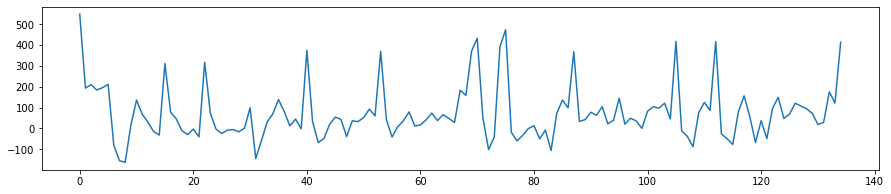

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
plt.plot(results['0.64'].residuals)
plt.figure(figsize=(15, 3))
plt.plot(results['0.64'].whitened_residuals)
#results['-0.01'].residuals

## create DM and add it to confounds

`confounds` of `clean_ts = signal.clean(timeseries.T, confounds=fmriprep_confounds).T` in `cleanTS()` of the gradient fitting procedure

In [180]:
fmriprep_confounds_include = ['global_signal', 'dvars', 'framewise_displacement', 'trans_x',
                                'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
                                'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'cosine00', 'cosine01', 'cosine02'
                                ]
number_of_vertex = 20484
space = 'fsaverage5'
sub='01'
ses=1
run=1

In [173]:
import nibabel as nib
from nilearn import signal

timeseries = [None] * 2
for i, hemi in enumerate(['L', 'R']):
    filename = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', 
    f'sub-{sub}_ses-{ses}_task-risk_run-{run}_space-{space}_hemi-{hemi}_bold.func.gii')        
    timeseries[i] = nib.load(filename).agg_data()
timeseries = np.vstack(timeseries) # (20484, 135)

fmriprep_confounds_file = op.join(bids_folder,'derivatives', 'fmriprep', f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_desc-confounds_timeseries.tsv')
fmriprep_confounds = pd.read_table(fmriprep_confounds_file)[fmriprep_confounds_include] 
fmriprep_confounds= fmriprep_confounds.fillna(method='bfill')

print(len(fmriprep_confounds))
fmriprep_confounds.head()

135


,global_signal,dvars,framewise_displacement,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,cosine00,cosine01,cosine02
0,1156.801464,25.996767,0.088703,-0.053118,-0.042646,-0.128288,-0.000592,-0.000372,0.000933,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1158.820654,25.996767,0.088703,-0.044338,-0.029004,-0.146589,-0.001124,-0.000242,0.000635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1161.072197,26.437101,0.150294,-0.022338,-0.045064,-0.138150,-0.000287,0.000826,0.000806,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1159.242018,28.858858,0.150398,-0.008001,-0.024556,-0.164139,0.000133,-0.000285,0.000545,-0.159094,-0.026350,0.194394,-0.008760,0.123083,0.123057,0.123013
4,1165.400732,35.953186,0.433023,-0.145950,0.046449,-0.267900,-0.000733,-0.001267,0.001103,-0.157304,-0.095899,0.101210,-0.036154,0.123013,0.122778,0.122386


In [235]:
df_events = pd.read_csv(op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-1_events.tsv'.format(sub=sub, ses=ses)), sep='\t')
#df_events.set_index(['trial_type'],inplace=True)
df_events.head()

,trial_nr,onset,trial_type,prob1,prob2,n1,n2,choice
0,1,13.262186,stimulus 1,0.55,1.0,13.0,10.0,NaN
1,1,19.467741,stimulus 2,0.55,1.0,13.0,10.0,NaN
2,1,19.944715,choice,NaN,NaN,NaN,NaN,2.0
3,2,25.923746,stimulus 1,0.55,1.0,8.0,7.0,NaN
4,2,35.115593,stimulus 2,0.55,1.0,8.0,7.0,NaN


In [229]:
#stimulus1 = df_events.xs('stimulus 1', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n1']]
stimulus1 = df_events.loc[df_events['trial_type'] == 'stimulus 1', ['onset', 'trial_nr', 'trial_type', 'n1']]
stimulus1['duration'] = 0.6 + 0.8
stimulus1['onset'] = stimulus1['onset'] - 0.8 # cause we want to take the onset of the piechart 
stimulus1['stim_order'] = int(1)
stimulus1_int = stimulus1.copy()
stimulus1_int['trial_type'] = 'stimulus1_int'
stimulus1_int['modulation'] = 1
stimulus1_mod= stimulus1.copy()
stimulus1_mod['trial_type'] = 'stimulus1_mod'
stimulus1_mod['modulation'] = stimulus1['n1']

#choices = df_events.xs('choice', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]
choices = df_events.loc[df_events['trial_type'] == 'choice']

#stimulus2 = df_events.xs('stimulus 2', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]
stimulus2 = df_events.loc[df_events['trial_type'] == 'stimulus 2', ['onset', 'trial_nr', 'trial_type', 'n2']]
stimulus2['duration'] = choices.set_index('trial_nr')['onset']- stimulus2.set_index('trial_nr')['onset'] + 0.6 # 0.6 + 0.6 ## looked at the data, is is different for stim 1 and 2... ?!!
stimulus2['onset'] = stimulus2['onset'] - 0.6
stimulus2['stim_order'] = int(2)
stimulus2_int = stimulus2.copy()
stimulus2_int['trial_type'] = 'stimulus2_int'
stimulus2_int['modulation'] = 1
stimulus2_mod= stimulus2.copy()
stimulus2_mod['trial_type'] = 'stimulus2_mod'
stimulus2_mod['modulation'] = stimulus2['n2']

events = pd.concat((stimulus1_int,stimulus1_mod, stimulus2_int, stimulus2_mod)).set_index(['trial_nr','stim_order'],append=True).sort_index()

onsets = events[['onset', 'duration', 'trial_type', 'modulation']]
onsets['onset'] = ((onsets['onset']+tr/2.) // 2.3) * 2.3
onsets.head()   

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_6821/1092065119.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  onsets['onset'] = ((onsets['onset']+tr/2.) // 2.3) * 2.3


onset  duration     trial_type  modulation
  trial_nr stim_order                                            
0 1        1            11.5  1.400000  stimulus1_int         1.0
           1            11.5  1.400000  stimulus1_mod        13.0
1 1        2            18.4  1.076974  stimulus2_int         1.0
           2            18.4  1.076974  stimulus2_mod        10.0
3 2        1            25.3  1.400000  stimulus1_int         1.0

In [230]:
tr = 2.3 # repetition Time
n = 135  # number of slices
frametimes = np.linspace(tr/2., (n - .5)*tr, n)

from nilearn.glm.first_level import make_first_level_design_matrix
dm = make_first_level_design_matrix(frametimes, onsets, 
                                     hrf_model='spm + derivative + dispersion', 
                                     oversampling=100.,drift_order=1, 
                                     drift_model=None).drop('constant', axis=1)
dm /= dm.max()
print(dm.shape)

A 'modulation' column was found in the given events data and is used.
(135, 12)


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/first_level/experimental_paradigm.py:117: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  warnings.warn("Duplicated events were detected. "


In [243]:
regressors_to_remove = pd.concat([dm.reset_index(drop=True), fmriprep_confounds], axis=1)
#regressors_to_remove.head()

clean_ts = signal.clean(timeseries.T, confounds=regressors_to_remove).T
clean_ts.shape

clean_ts_onlyFmriprep = signal.clean(timeseries.T, confounds=fmriprep_confounds).T


(20484, 135)

In [ ]:
# mark events in the timeseries plot

scale1_range = list(dm.index)[-1] - list(dm.index)[0]
scale2_range = 135 - 1

x_2s = []
for trial_nr in range(1,21):
    for stim_order in [1, 2]:
        x_1 = onsets.loc[(trial_nr, stim_order), 'onset'].values[0]
        x_2 = ((x_1-list(dm.index)[0]) * scale2_range / scale1_range) + 1
        x_2s.append(x_2)

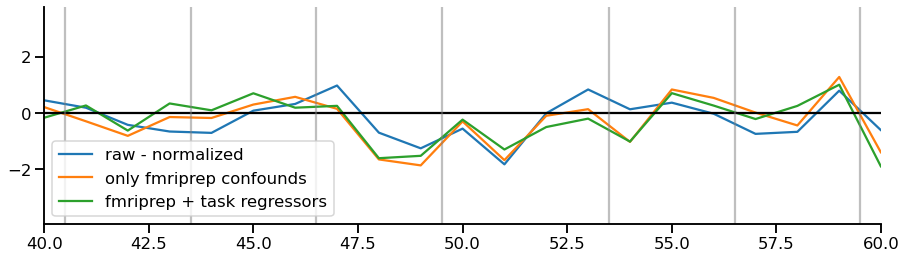

In [309]:
plt.figure(figsize=(15, 4))

vertex_n = 560
plt.plot((timeseries[vertex_n]- np.mean(timeseries[vertex_n])) / np.std(timeseries[vertex_n]), label='raw - normalized')
plt.plot(clean_ts_onlyFmriprep[vertex_n], label='only fmriprep confounds')
plt.plot(clean_ts[vertex_n], label='fmriprep + task regressors')
plt.legend()
plt.xlim(40,60)
plt.axhline(y=0, color='black') 
for x in x_2s:
    plt.axvline(x=x, color='grey', alpha=0.5)  # Here 'r' is the color red
sns.despine()


In [306]:
# get a vertex with high r2 from nPRF, preferably in IPS
from nilearn import datasets

atlas = datasets.fetch_atlas_surf_destrieux()
labeling = np.concatenate([atlas['map_left'], atlas['map_right']]) # table with regions and names: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2937159/

ips_mask = np.isin(labeling, atlas.labels.index(b'S_intrapariet_and_P_trans'))
indices = [i for i, x in enumerate(ips_mask) if x]
len(indices) # 573

# get the vertex with the highest r2


573

In [307]:
indices

[18,
 67,
 71,
 102,
 134,
 187,
 292,
 293,
 294,
 409,
 410,
 411,
 417,
 477,
 480,
 481,
 560,
 561,
 562,
 564,
 772,
 773,
 774,
 922,
 923,
 924,
 934,
 935,
 936,
 1053,
 1239,
 1240,
 1241,
 1242,
 1243,
 1244,
 1246,
 1489,
 1490,
 1497,
 1678,
 1679,
 1680,
 1681,
 1682,
 1915,
 1916,
 1917,
 1918,
 1920,
 2078,
 2079,
 2087,
 2088,
 2089,
 2090,
 2091,
 2094,
 2095,
 2319,
 2320,
 2321,
 2322,
 2323,
 2324,
 2325,
 2327,
 2328,
 2329,
 2332,
 2692,
 2693,
 2694,
 2842,
 2843,
 2844,
 2852,
 2854,
 2855,
 2856,
 3157,
 3158,
 3159,
 3160,
 3161,
 3162,
 3163,
 3164,
 3442,
 3443,
 3456,
 3757,
 3758,
 3759,
 3760,
 3761,
 3762,
 3763,
 3764,
 4207,
 4208,
 4209,
 4210,
 4211,
 4212,
 4216,
 4247,
 4567,
 4568,
 4569,
 4588,
 4589,
 4590,
 4591,
 4592,
 4593,
 4594,
 4595,
 4596,
 4597,
 4598,
 4599,
 4608,
 5155,
 5156,
 5157,
 5158,
 5159,
 5160,
 5161,
 5162,
 5163,
 5164,
 5165,
 5166,
 5167,
 5168,
 5169,
 5170,
 5171,
 5172,
 5175,
 5176,
 5177,
 5179,
 5180,
 5181,
 51

## plot results